In [1]:
import os
import datetime
import numpy as np
from tqdm import tqdm
from matplotlib import patches
from omegaconf import OmegaConf
import matplotlib.pyplot as plt

from explore.env.mujoco_sim import MjSim
from explore.utils.vis import AdjMap, play_path
from explore.datasets.utils import cost_computation, load_trees, build_path, generate_adj_map, get_feasible_paths

dataset = "/home/sayantan/Downloads/fingerRamp_full"

config_path = os.path.join(dataset, ".hydra/config.yaml")
cfg = OmegaConf.load(config_path)

ERROR_THRESH = cfg.RRT.min_cost

look_at_specific_start_idx = cfg.RRT.start_idx
look_at_specific_end_idx = cfg.RRT.end_idx
look_at_specific_end_idx = -1

q_mask = np.array(cfg.RRT.q_mask)
sim_cfg = cfg.RRT.sim

mujoco_xml = os.path.join("..", sim_cfg.mujoco_xml)

print(f"Looking at start_idx {look_at_specific_start_idx} and end_idx {look_at_specific_end_idx} with error threshold {ERROR_THRESH}.")
print(f"Tau action: {cfg.RRT.sim.tau_action}; Tau sim: {cfg.RRT.sim.tau_sim}")

Looking at start_idx -1 and end_idx -1 with error threshold 0.02.
Tau action: 0.5; Tau sim: 0.001


## Load data

In [2]:
tree_dataset = os.path.join(dataset, "trees")
trees, tree_count, total_nodes_count = load_trees(tree_dataset, 1)

if not q_mask.shape[0]:
    q_mask = np.ones_like(trees[0][0]["state"][1])

print("Loaded ", total_nodes_count, " RRT nodes.")

time_taken = float(np.loadtxt(os.path.join(dataset, "time_taken.txt")))
print(f"Time taken to generate tree: {datetime.timedelta(seconds=time_taken)}")

Tree Count: 26
Loaded  500006  RRT nodes.
Time taken to generate tree: 0:00:01


## Cost evolution over nodes

In [3]:
if look_at_specific_start_idx != -1:
    si = look_at_specific_start_idx

    costs_over_time = []
    for i, node in tqdm(enumerate(trees[si])):

        costs = []
        
        for target_idx in range(tree_count):
            cost = cost_computation(trees[target_idx][0], node, q_mask)
            if i == 0 or costs_over_time[i-1][target_idx] > cost:
                costs.append(cost)
            else:
                costs.append(costs_over_time[i-1][target_idx])

        costs_over_time.append(costs)
    
    # Subtract 1 because it also contains a cost against itself
    mean_cost_over_time = [sum(costs)/(len(costs)-1) for costs in costs_over_time]
    found_paths_over_time = [len([1 for c in costs if c < ERROR_THRESH])-1 for costs in costs_over_time]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].set_title(f"Avg. Cost Over Time for Start Node {look_at_specific_start_idx}")
    axes[0].plot(mean_cost_over_time, label="Mean Cost")
    
    if cfg.RRT.end_idx != -1:
        cost_for_target_over_time = [costs[cfg.RRT.end_idx] for costs in costs_over_time]
        axes[0].plot(cost_for_target_over_time, label=f"Target {cfg.RRT.end_idx}")
    
    axes[0].axhline(y=ERROR_THRESH, color="red", linestyle="--", label="Success Threshhold")
    axes[0].legend()
    
    axes[1].set_title(f"Found Paths Over Time for Start Node {look_at_specific_start_idx}")
    axes[1].plot(found_paths_over_time)

    plt.tight_layout()
    plt.show()

## Costs for all config pairs (without clustering)

Loading cached Adjacency Map...


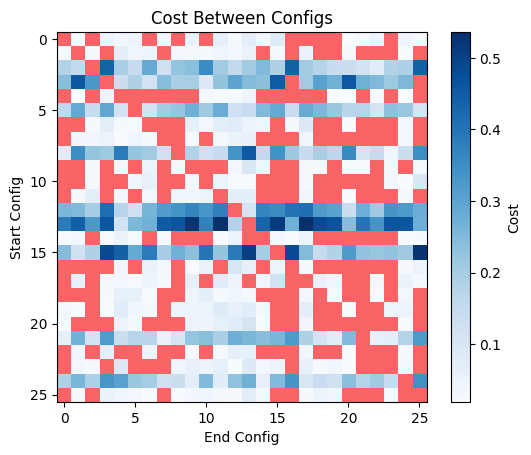

In [4]:
min_costs, top_nodes = generate_adj_map(trees, q_mask, check_cached=dataset)
min_costs = np.array(min_costs)

AdjMap(min_costs, ERROR_THRESH, min_costs.max())

## Clustering

In [5]:
colors = [-1 for _ in range(tree_count)]

max_color_idx = 0
for i in range(tree_count):
        
    if colors[i] == -1:
        colors[i] = max_color_idx
        max_color_idx += 1
        
        for j in range(tree_count):
            if i != j and min_costs[i][j] <= ERROR_THRESH:
                if colors[j] != -1:
                    c = colors[j]
                    for k in range(tree_count):
                        if colors[k] == c:
                            colors[k] = colors[i]
                else:
                    colors[j] = colors[i]

groups = []
for c in colors:
    if not c in groups:
        groups.append(c)

group_sizes = [0 for _ in groups]
for c in colors:
    group_sizes[groups.index(c)] += 1

# print(colors)
# print(groups)
print("Group Count: ", len(groups))
print("Group Sizes: ", group_sizes)

Group Count:  4
Group Sizes:  [23, 1, 1, 1]


## Looking at specific start and end configurations

In [6]:
start_idx = look_at_specific_start_idx
end_idx = look_at_specific_end_idx

if look_at_specific_start_idx != -1:
    costs = [min_costs[start_idx][i] for i in range(tree_count) if start_idx != i]
    print(f"Mean costs for start config {start_idx}: {sum(costs)/tree_count}, (Min: {min(costs)}, Max {max(costs)})")
    labels = [str(i) for i in range(tree_count) if i != start_idx]
    
    highlight_labels = {str(end_idx)}
    colors = ["red" if label in highlight_labels else "blue" for label in labels]
    plt.figure(figsize=(25, 5))
    plt.bar(labels, costs, color=colors)
    plt.xticks(rotation=90, ha="right")
    plt.axhline(y=ERROR_THRESH, color="red", linestyle="--")
    plt.title(f"Costs to reach each end config from start config {start_idx}")
    plt.xlabel("Config idx")
    plt.ylabel("Cost")
    plt.show()

    if end_idx != -1:
        print(f"Cost for target {end_idx} with start {start_idx}: {costs[end_idx]}")

## Collecting top paths

In [7]:
traj_pairs, end_nodes, top_costs = get_feasible_paths(
                min_costs, top_nodes, look_at_specific_start_idx, look_at_specific_end_idx, ERROR_THRESH)

top_paths = []
top_paths_start = []
top_paths_goal = []
for i, path_data in enumerate(traj_pairs):

    start_idx = path_data[0]
    end_idx = path_data[1]
    if start_idx == end_idx: continue
    
    tree = trees[start_idx]
    
    path = build_path(tree, end_nodes[i])

    top_paths.append(path)
    top_paths_start.append(start_idx)
    top_paths_goal.append(end_idx)

target_counts = []
for i, path in enumerate(top_paths):
    goal_idx = top_paths_goal[i]
    target_counts.append(0)
    for node in path:
        if goal_idx == node["target_config_idx"]:
            target_counts[-1] += 1

percs = [float(np.round(c/len(top_paths[i])*100)) for i, c in enumerate(target_counts)]
percs.sort()
percs.reverse()

possible_paths = tree_count**2 - tree_count
print("Top costs: ", [float(c) for c in top_costs])
print("Found Trajectories Count: ", len(top_paths), " of ", possible_paths)
if look_at_specific_start_idx == -1:
    print("When considering full graph: ", sum([v**2 for v in group_sizes]) - tree_count, " of ", possible_paths)

if not top_paths:
    print("No trajectories found!")

else:
    print("Percentage of reached config used as target: ", percs)
    print("Avg. use of reached config as target: ", sum(percs)/len(percs))

    path_lens = [len(p) for p in top_paths]

    # print("Path lens: [", end="")
    # for i in range(len(top_paths)):
    #     end = "]\n" if i == len(top_paths)-1 else ", "
    #     print(f"{path_lens[i]} ({top_paths_start[i]}, {top_paths_goal[i]})", end=end)

    path_lens_copy = path_lens.copy()
    path_lens_copy.sort()
    path_lens_copy.reverse()
    print("Path lengths: ", path_lens_copy)
    print("Avg. Path length: ", sum(path_lens_copy)/len(path_lens_copy))

Top costs:  [0.006106650024449739, 0.009169380426878676, 0.003042531483319913, 0.004980096695576752, 0.002259838047801943, 0.011592477958304717, 0.018368563808900396, 0.010342626537501967, 0.006113282275390597, 0.009385749029099694, 0.007721883155875756, 0.011051226177670459, 0.009632478265339459, 0.010706437313081338, 0.010327735036728111, 0.0034844950220481175, 0.01052778183513943, 0.007585195834722093, 0.008277219336605246, 0.005279485290512304, 0.009755114407919652, 0.0040488375879604716, 0.019596633601394187, 0.00970402367808781, 0.016272033855404516, 0.014038830388223674, 0.014845310001098483, 0.016165975325109053, 0.008341031794038445, 0.01182693704510479, 0.007351127538419225, 0.017794940090695766, 0.01446436058101, 0.008986716249319137, 0.003089326048505203, 0.016708268409917626, 0.015918155550837004, 0.018699930434918355, 0.008021735808315597, 0.0031272839411510406, 0.008536674109691833, 0.008991265886575978, 0.014049505420092756, 0.0129805703021268, 0.01949956562989627, 0.00

## Sample a single path

In [8]:
path = []
min_path_len = 10

if not top_paths:
    print("No good paths no analyse!")

else:
    valid_path_idxs = [i for i, l in enumerate(path_lens) if l >= min_path_len]

    path_idx = np.random.choice(valid_path_idxs)
    path = top_paths[path_idx]
    start_idx = top_paths_start[path_idx]
    end_idx = top_paths_goal[path_idx]
    e_vec = trees[end_idx][0]["state"][1] - path[-1]["state"][1]

    print("---- Sampled Path Data ----")
    print("Target config ids: ", [n["target_config_idx"] for n in path])
    print("Start idx: ", start_idx)
    print("End idx: ", end_idx)
    print("Cost: ", top_costs[path_idx])
    print("Error vec: ", e_vec)
    print("Error vec (with mask): ", e_vec * q_mask)
    print("Sampled Path Length: ", len(path))

---- Sampled Path Data ----
Target config ids:  [-1, 24, 10, 10, 3, 3, 3, 23, 7, 23, 7, 7, 19, 7]
Start idx:  6
End idx:  19
Cost:  0.014049505420092756
Error vec:  [ 0.01404951  0.00868291  0.00484282  0.01223314  0.00918693  0.00508938
  0.57593697  0.29378481 -0.55606792 -0.85760008]
Error vec (with mask):  [ 0.01404951  0.00868291  0.00484282  0.01223314  0.00918693  0.00508938
  0.          0.         -0.         -0.        ]
Sampled Path Length:  14


Playing path with length 14


libdecor-gtk-WARNING: Failed to initialize GTK
Failed to load plugin 'libdecor-gtk.so': failed to init
No plugins found, falling back on no decorations


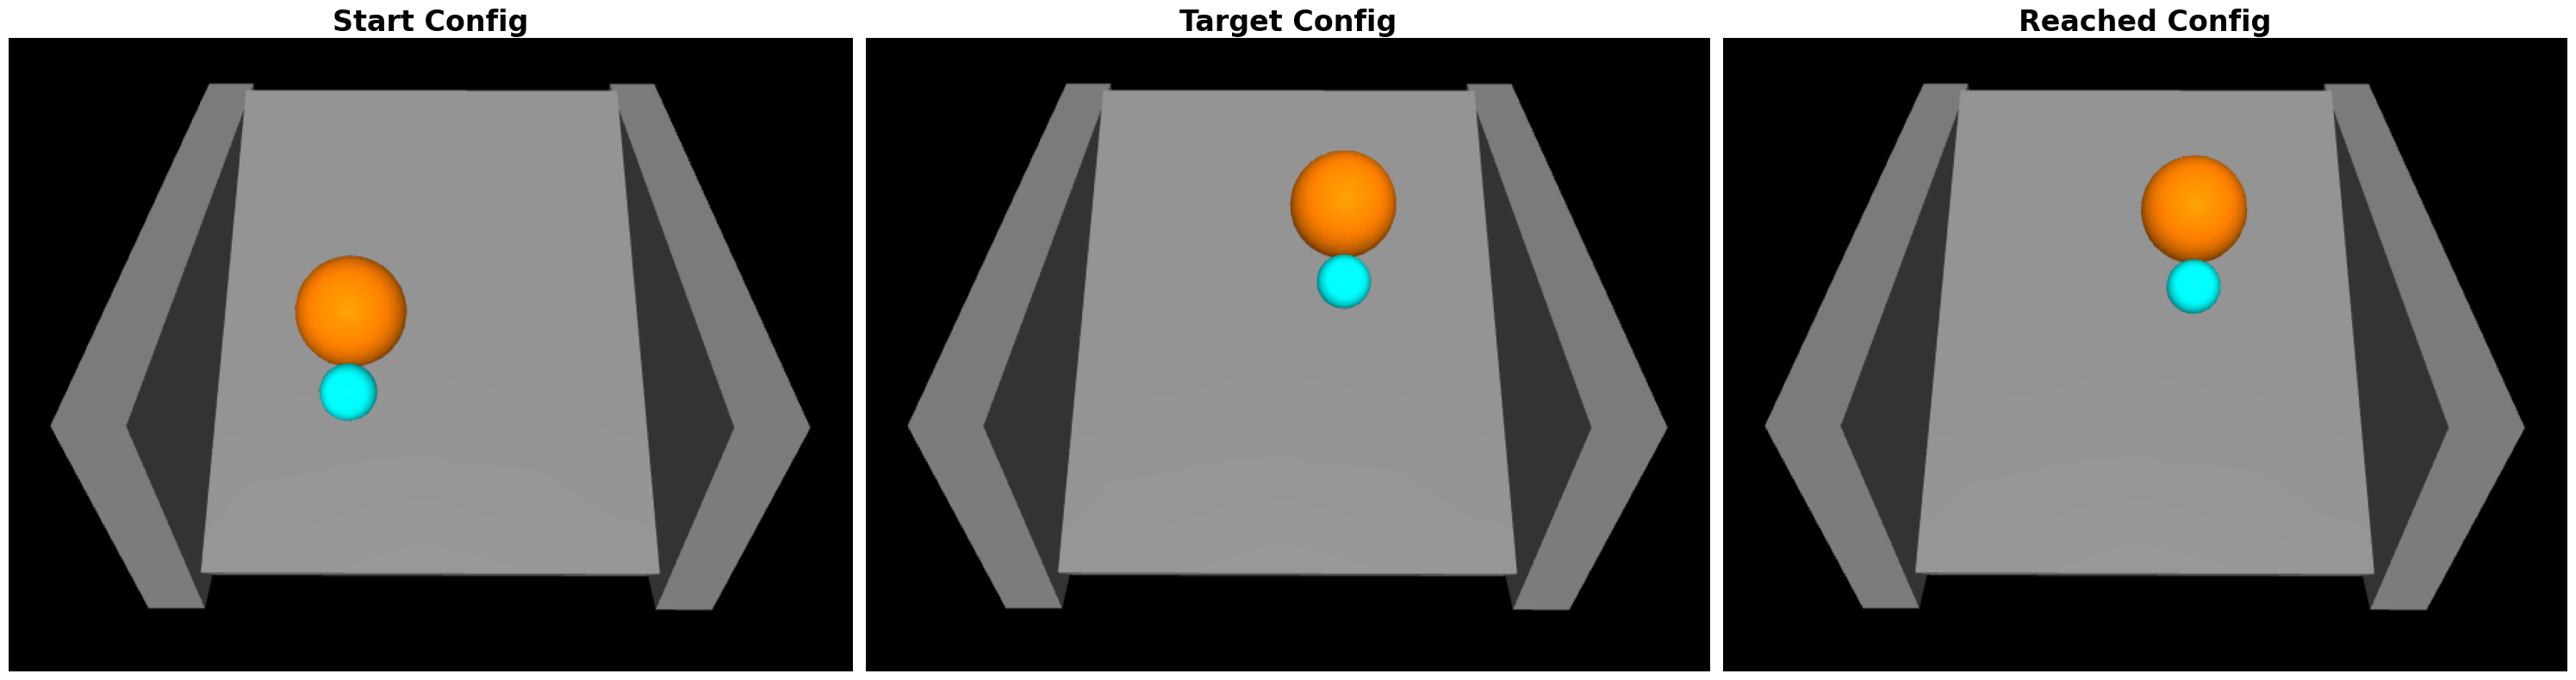

In [9]:
if path:
    start_state = trees[start_idx][0]["state"][1]
    target_state = trees[end_idx][0]["state"][1]
    sim = MjSim(
        mujoco_xml, tau_sim=sim_cfg.tau_sim, interpolate=sim_cfg.interpolate_actions,
        joints_are_same_as_ctrl=sim_cfg.joints_are_same_as_ctrl, view=False
    )
    play_path(path, sim, start_state, target_state, tau_action=sim_cfg.tau_action, camera=cfg.RRT.sim.camera, reset_state=True)

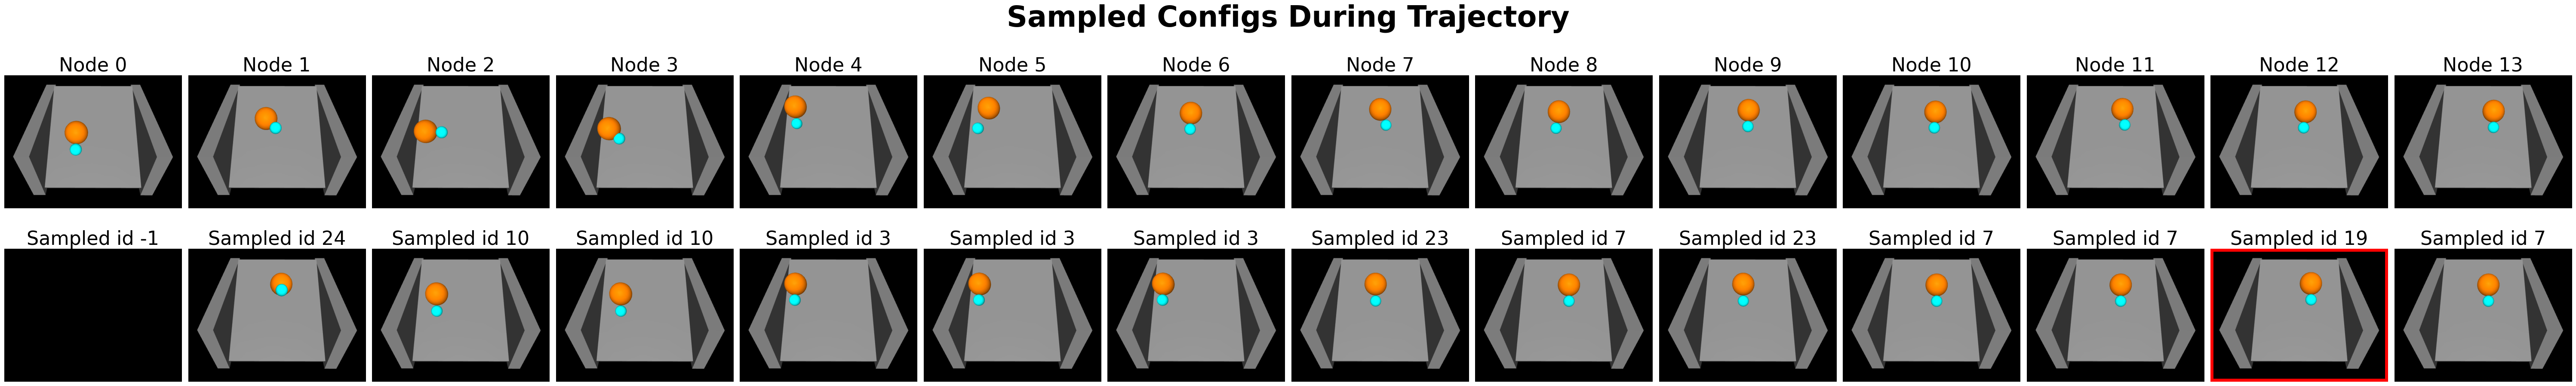

In [10]:
if path:
    fig, axes = plt.subplots(2, len(path), figsize=(60, 10))
    for i, node in enumerate(path):

        fig.suptitle("Sampled Configs During Trajectory", fontsize=48, fontweight="bold")

        sim.pushConfig(node["state"][1])
        im_state = sim.renderImg()

        axes[0, i].set_title(f"Node {i}", fontsize=32)
        axes[0, i].imshow(im_state)
        axes[0, i].axis("off")

        tci = node["target_config_idx"]
        axes[1, i].set_title(f"Sampled id {tci}", fontsize=32)
        axes[1, i].axis("off")
        if tci != -1:
            sim.pushConfig(trees[tci][0]["state"][1])
            im_target = sim.renderImg()
            
            if tci == end_idx:
                rect = patches.Rectangle(
                    (0, 0), 1, 1,
                    transform=axes[1, i].transAxes,
                    linewidth=10,
                    edgecolor="red",
                    facecolor="none"
                )
                axes[1, i].add_patch(rect)
        else:
            im_target = np.zeros_like(im_state)
        axes[1, i].imshow(im_target)
        
    plt.tight_layout()
    plt.show()

## Bi-directional analysis

In [11]:
bidir = cfg.RRT.bidirectional and cfg.RRT.start_idx != -1 and cfg.RRT.start_idx != -1
if bidir:
    si = cfg.RRT.start_idx
    ei = cfg.RRT.end_idx
    bi_tree_tolerance = cfg.RRT.bi_tree_tolerance

    bi_tree_dataset = os.path.join(dataset, "bi_trees")
    bi_trees, bi_tree_count, bi_total_nodes_count = load_trees(bi_tree_dataset)

    print(f"Starting bi-directional analysis for trees with sizes {len(trees[si])} and {len(bi_trees[ei])}")

    # Find connections to target without the bi-tree
    found_direct_nodes_ids = []
    for id, node in enumerate(trees[si]):
        cost_to_target = cost_computation(node, trees[ei][0], q_mask)
        if cost_to_target <= ERROR_THRESH:
            found_direct_nodes_ids.append(id)

    # Find connections using the bi-tree
    found_bi_nodes_ids = []
    min_cost_between_trees = 1e6
    for id, node in tqdm(enumerate(trees[si])):
        for bi_id, bi_node in enumerate(bi_trees[ei]):
            
            cost_to_target = cost_computation(node, bi_node, q_mask)
            if cost_to_target <= bi_tree_tolerance:
                found_bi_nodes_ids.append((id, bi_id))
            
            if min_cost_between_trees > cost_to_target:
                min_cost_between_trees = cost_to_target

    print(f"------ Bi-Tree status for path from config {si} to {ei} ------")
    print(f"Node count in bi-tree: {len(bi_trees[ei])}")
    print(f"Found paths without bi-tree: {len(found_direct_nodes_ids)}")
    print(f"Found paths with bi-tree: {len(found_bi_nodes_ids)}")
    print(f"Minimum cost between trees: {min_cost_between_trees}")

In [12]:
if bidir and found_bi_nodes_ids:
    # Build full trajectory
    connection_idx = np.random.randint(0, len(found_bi_nodes_ids))
    id = found_bi_nodes_ids[connection_idx][0]
    bi_id = found_bi_nodes_ids[connection_idx][1]
    path_to = build_path(trees[si], id)
    path_from = build_path(bi_trees[ei], bi_id, reverse=False)
    full_path = path_to + path_from
    print(f"Percentage forward tree: {len(path_to)/len(full_path)*100:.2f} ({len(path_to)}/{len(full_path)})")

    # Play trajectory
    start_state = trees[si][0]["state"][1]
    target_state = trees[ei][0]["state"][1]
    sim = MjSim(
        mujoco_xml, tau_sim=sim_cfg.tau_sim, interpolate=sim_cfg.interpolate_actions,
        joints_are_same_as_ctrl=sim_cfg.joints_are_same_as_ctrl, view=False
    )
    play_path(full_path, sim, start_state, target_state, tau_action=sim_cfg.tau_action,
              camera=cfg.RRT.sim.camera, save_as="bi_path.gif", reset_state=False)
    
    # TODO: Glue trajectory nodes with BBO